> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy pandas


In [ ]:
# Fetch this case's data files when they are not already next to the notebook.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/en/Warehouse_Network_Management_Problem/'
FILES = [
    'data/df_customer.csv',
    'data/df_list.csv',
    'data/df_loc.csv',
    'data/df_matrix.csv',
    'data/df_order.csv',
    'data/df_order_full.csv',
    'data/df_parameter.csv',
    'data/df_past_order.csv',
    'data/df_proc.csv',
    'data/df_wh.csv',
    'data/┤ª╓├╜ß╣√-271.csv',
    'data/╣⌐╙ª╣╪╧╡-271.csv',
    'data/╩▒╨º▒φ.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')

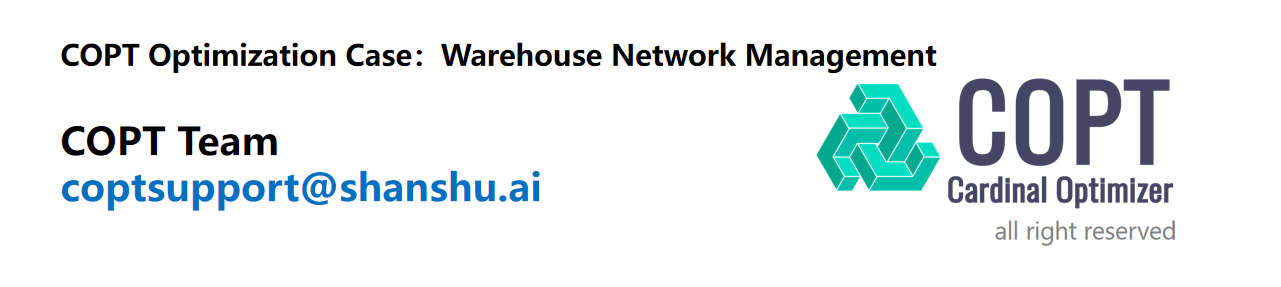

# Code Implementation of Warehouse Network Management Problem
## The steps for solving the warehouse network management problem using COPT modeling

1. **Import the COPT-Python interface library** `coptpy`

2. **Import Data**
    - Import CSV data
    - Data parsing, cleansing and integration

3. **Create COPT Solving Environment and Model**

4. **Build the model and add the three elements of the model in sequence**
    - **Decision Variables**：We define the following variables:
        - $\text{wh}_i$ : Whether warehouse $i$ is enabled, Binary.
        - $\text{w\_cust}_{i,k,s}$ : Whether warehouse $i$ serves the goods $s$ for customer city $k$, Binary.
        - $\text{d\_cust}_{i,k,s}$ : Actual quantity of goods $s$ supplied by warehouse $i$ to customer city $k$, Continuous.
        - $\text{qty\_dc}_{i,j,s}$ : Quantity of goods $s$ received by RDC $j$ from CDC $i$, Continuous.
        - $\text{qty\_cdc}_{i,s}$ : Quantity of goods $s$ disposed by CDC $i$, Continuous.
        - $\text{procure}_i$ : Whether warehouse $i$ uses the intelligent scheduling system, Binary.
        - $\text{proc}_i$ : Actual processing volume included in the disposal cost of warehouse $i$, Continuous.
    - **Objective Function**：Minimize total cost
        - **Mainline Transport Cost**(CDC — RDC)
        - **Warehouse - Customer City Delivery Cost** 
        - **Fixed Warehouse Opening Cost**
        - **Product disposal Cost** (considering discounts from the intelligent system)
        - **Intelligent System Procurement Cost** 
    - **Constraints**：
        - **Mandatory Hub activation Constraint**
        - **Unique Sourcing & Product Category Compliance Constraints**
        - **Demand Satisfaction Constraint**
        - **Lead Time Satisfaction Constraint**
        - **Warehouse Activation, Service Relationship and Actual Supply Volume Binding Constraints**
        - **Flow Conservation Constraint**
        - **Handling Volume Limit Constraint**
        - **Intelligent Scheduling System Procurement Decisions Constraint**

5. **Solve**

6. View and analyze solution **results**


## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

import warnings

# Ignore all UserWarnings related to the inability to find the font
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.*")

## Add Model Data

### Data Import

In [6]:
# Order data
data = "data"
df_demand = pd.read_csv(f'{data}/df_order.csv')
# Customer data
df_customer =pd.read_csv(f'{data}/df_customer.csv')
# Facility data
df_wh = pd.read_csv(f'{data}/df_wh.csv')
# Lead Time Information & Distance Matrix
df_matrix = pd.read_csv(f'{data}/df_matrix.csv')
# Warehouse data
df_proc = pd.read_csv(f'{data}/df_proc.csv')
# Parameter data
df_para = pd.read_csv(f'{data}/df_parameter.csv')
# Pinyin correspondence data
df_list = pd.read_csv(f'{data}/df_list.csv', encoding='gbk')

| Data Table Type | Data Table Name | Function | 
| --- | --- | --- |
| **Warehouse Node Table** | `df_wh` | Stores information about CDC and candidate RDCs of the warehouse nodes, which is used to generate `cdc_list`, `dc_list`, and to determine which warehouses can be enabled. |
| **Customer City Table** | `df_customer` | Stores customer city information, which is used to generate `cust_list`, that is, the set of customer cities that the model needs to serve. |
| **Order / Demand Table** | `df_demand` | Stores the demand quantities for different customer cities and different SKUs, which is used to generate the demand parameter `D[k,s]`. |
| **Distance / Lead Time Matrix Table** | `df_matrix` | This table stores information such as distances and transportation durations between nodes, which are used to calculate transportation costs `Cost_trans` and efficiency parameters `Dura` and `Dura_ind`. |
| **Warehouse Processing Capacity and Cost Table** | `df_proc` | Stores information such as warehouse storage capacity, fixed costs for warehouse activation, commodity disposal costs, and processing parameters related to the intelligent scheduling system. |
| **Global Parameter Table** | `df_parameter` | Stores global parameters such as time limit standards, service level ratios, Big-M constants, transportation unit prices, costs or discount parameters for the intelligent dispatching system, etc. |

### Data Cleaning

In [9]:
# Read various constants from the file
P_dura = df_para['Lead_Time_Satisfaction_Rate'][0]
Dura_std = df_para['Customer_Supply_Lead_Time_Requirement'][0]
Cost_centre_cetre = df_para['Inter_Warehouse_Transfer_Cost'][0]
Cost_centre_cust = df_para['Warehouse_to_Customer_Transfer_Cost'][0]
CONST_M = df_para['Slack_Variable_M'][0]
Procure_cost = df_para['Scheduling_System_Procurement_Cost'][0]
save_percent = df_para['Disposal_Cost_Saving_Ratio'][0]

# Location Sets
## Select CDC indices
df_CDC = df_wh[df_wh['Type']=='CDC']
# Select RDC indices, including CDC
df_RDC = df_wh[df_wh['Type'].isin(['CDC','RDC'])]

# Convert series to list, extract names for decision variable construction
dc_list = list(df_RDC['Name'])
cdc_list = list(df_CDC['Name'])
cust_list = list(df_customer['Name'])

# Product Type Set (Domestic or Imported)
sku_list = list(df_demand['SKU'].unique())

# Demand Information
D = {}
for i,row in df_demand.iterrows():
    D[(row['Name'], row['SKU'])]=row['qty']

# Transport Lead Time & Cost
Dura = {}
Cost_trans = {}
for i,row in df_matrix.iterrows():
    Dura[(row['From'],row['To'])] = row['Duration']
    if row['To'] in dc_list:
        cost_per = Cost_centre_cetre
    else:
        cost_per = Cost_centre_cust
    # Calculate the inter-warehouse transportation cost of CDC - RDC or the distribution cost from the warehouse to the customer's city
    Cost_trans[(row['From'],row['To'])] = row['Distance'] * cost_per

# Transport Lead Time Indicator
Dura_ind = {}
for key, value in Dura.items():
    if value <= Dura_std:
        Dura_ind[key] = 1
    else:
        Dura_ind[key] = 0

If the transportation time of a certain route is less than or equal to the standard lead time limit, it is recorded as 1; if it exceeds the standard time limit, it is recorded as 0. 

The ingenious part of this approach lies in the fact that the subsequent time constraints can be written very simply. The model only needs to calculate: how much of the goods have traveled along the approved routes, and whether the proportion of this amount to the total demand meets the requirements. The essence of this step is to place "business judgment" before the data processing, and keep the model's internal structure as a linear expression as much as possible.

In [11]:
# Warehouse costs, capacity and fixed cost activation
Proc_cost = {}
Cap = {}
Cost_wh = {}
for i,row in df_proc.iterrows():
    Proc_cost[row['Name']] = row['Processing_fee']
    Cap[row['Name']] = row['Capacity']
    Cost_wh[row['Name']] = row['Opening_fee']

# Business-specific collection: Allowed CDC - RDC - product type flows, as well as the correspondence between CDC and product types
dc_flow_idx =[]
cdc_sku_pair = [(cdc_list[0],'dm'),(cdc_list[1],'im')]
for (i,s) in cdc_sku_pair:
    for j in dc_list:
        if i!=j:
            dc_flow_idx.append((i,j,s))            

In the model, do not blindly generate all possible variables, but only generate the variables that are truly allowed to occur in the business. This approach has two benefits.
1. Model is more in line with business logic, and there will be no unreasonable scenarios such as "Port CDC sending domestic goods" or "Inland CDC sending imported goods".
2. Model is smaller in scale because many meaningless variables have been omitted, resulting in better solution speed and readability.

In [13]:
# Define function to match Pinyin with English descriptions
def py_en(x):
    if x == 'nei-lu-CDC':
        return 'Inland-CDC'
    elif x == 'gang-kou-CDC':
        return 'Port-CDC'
    elif x == 'nei-lu-CDC-suo-zai-cheng-shi' or x == 'gang-kou-CDC-suo-zai-cheng-shi':
        return x
    else:
        return x[:-3] + 'DC'

## Create the COPT Environment and COPT Model

In [15]:
env = cp.Envr()
model = env.createModel("Warehouse_network_management")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
1. $\text{wh}_i$ : Whether warehouse $i$ is enabled, Binary.

In [17]:
wh = model.addVars(dc_list, vtype=COPT.BINARY, nameprefix='wh')

2. $\text{w\_cust}_{i,k,s}$ : Whether warehouse $i$ serves the goods $s$ for customer city $k$, Binary.

In [19]:
w_cust = model.addVars(dc_list, cust_list, sku_list, vtype=COPT.BINARY, nameprefix='w_cust')

3. $\text{d\_cust}_{i,k,s}$ : Actual quantity of goods $s$ supplied by warehouse $i$ to customer city $k$, Continuous.

In [21]:
d_cust = model.addVars(dc_list, cust_list, sku_list, vtype=COPT.CONTINUOUS, nameprefix='d_cust')

4. $\text{qty\_dc}_{i,j,s}$ : Quantity of goods $s$ received by RDC $j$ from CDC $i$, Continuous.

In [23]:
qty_dc = model.addVars(dc_flow_idx, vtype=COPT.CONTINUOUS, nameprefix='qty_dc')

5. $\text{qty\_cdc}_{i,s}$ : Quantity of goods $s$ disposed by CDC $i$, Continuous.

In [25]:
qty_cdc = model.addVars(cdc_sku_pair, vtype=COPT.CONTINUOUS, nameprefix='qty_cdc')

6. $\text{procure}_i$ : Whether warehouse $i$ uses the intelligent scheduling system, Binary.

In [27]:
procure = model.addVars(dc_list, vtype=COPT.BINARY, nameprefix='procure')

7. $\text{proc}_i$ : Actual processing volume included in the disposal cost of warehouse $i$, Continuous.

In [29]:
proc = model.addVars(dc_list, vtype=COPT.CONTINUOUS, nameprefix='proc')

### Set Objective Function
1.	**Mainline Transport Cost**(CDC — RDC)
$$
    \text{cost\_cdc\_rdc} = \sum_{(i,j,s)\in \text{dc\_flow\_idx}} \text{qty\_dc}_{i,j,s} \cdot \text{Cost\_trans}_{i,j}
$$

In [31]:
cost_cdc_rdc = cp.quicksum(qty_dc[i, j, s] * Cost_trans[i, j] for (i, j, s) in dc_flow_idx)

2. **Warehouse - Customer City Delivery Cost**
$$
    \text{cost\_dc\_cust} = \sum_{i\in \text{dc\_list}} \sum_{k\in \text{cust\_list}} \sum_{s\in \text{sku\_list}} \text{d\_cust}_{i,k,s} \cdot \text{Cost\_trans}_{i,k}
$$

In [33]:
cost_dc_cust = cp.quicksum(d_cust[i, k, s] * Cost_trans[i, k] for i in dc_list for k in cust_list for s in sku_list)

3. **Fixed Warehouse Opening Cost**
$$
    \text{opening\_fee} = \sum_{i\in \text{dc\_list}} \text{wh}_i \cdot \text{Cost\_wh}_i
$$

In [35]:
opening_fee = cp.quicksum(wh[i] * Cost_wh[i] for i in dc_list)

4. **Product disposal Cost** (considering discounts from the intelligent system)
$$
    \text{in\_and\_out\_fee} = \sum_{i\in \text{dc\_list}} \text{proc}_i \cdot \text{Proc\_cost}_i
$$

In [37]:
in_and_out_fee = cp.quicksum(proc[i] * Proc_cost[i] for i in dc_list)

5. **Intelligent System Procurement Cost**
$$
    \text{sys\_fee} = \sum_{i\in \text{dc\_list}} \text{procure}_i \cdot \text{Procure\_cost}
$$

In [39]:
sys_fee = cp.quicksum(procure[i] * Procure_cost for i in dc_list)

#### Total Cost
The model aims to minimize the total operating cost:
$$
\begin{aligned}
\min\ \text{total\_cost}
=&\ \text{cost\_cdc\_rdc}
+\text{cost\_dc\_cust}\\
&+\text{opening\_fee}
+\text{in\_and\_out\_fee}
+\text{sys\_fee}
\end{aligned}
$$

In [41]:
total_cost = cost_cdc_rdc + cost_dc_cust + opening_fee + in_and_out_fee + sys_fee
model.setObjective(total_cost, sense=COPT.MINIMIZE)

### Add Constraints
1. **Mandatory Hub activation Constraint**：Inland CDC and Port CDC are two strategic hubs that must be activated.
$$
\begin{aligned}
\text{wh}_i
&=
1,
\quad
\forall i\in \text{cdc\_list}
\end{aligned}
$$

In [43]:
model.addConstrs(wh[i]==1 for i in cdc_list)

2. **Unique Sourcing & Product Category Compliance Constraints**：This group of constraints enforces two core business logics: each customer city’s demand for a single product category is fulfilled by exactly one warehouse, and each CDC only handles its designated product type.

Firstly, for each customer city $k$ and each type of commodity $s$, only one warehouse can be selected as the supply warehouse.
$$
\begin{aligned}
\sum_{i\in \text{dc\_list}}
\text{w\_cust}_{i,k,s}
&=
1,
\quad
\forall k\in \text{cust\_list}, s\in \text{sku\_list}
\end{aligned}
$$

Secondly, Inland CDC does not directly supply imported goods:
$$
\begin{aligned}
\text{w\_cust}_{\text{nei-lu-CDC},k,\text{im}}
&=
0,
\quad
\forall k\in \text{cust\_list}
\end{aligned}
$$

Finally, Port CDC does not directly supply domestic products:
$$
\begin{aligned}
\text{w\_cust}_{\text{gang-kou-CDC},k,\text{dm}}
&=
0,
\quad
\forall k\in \text{cust\_list}
\end{aligned}
$$

The above three constraints jointly ensure that each customer city has only one supply source for each type of commodity, and at the same time avoid business logic errors such as "inland CDC supplying imported goods" or "port CDC supplying domestic goods". If the RDC supplies to the customer city, its upstream source will be determined through subsequent CDC-RDC flow constraints and flow conservation constraints.

In [45]:
# Single Supply Source: For each customer city and each type of product, only one supply warehouse can be selected.
model.addConstrs(
    cp.quicksum(w_cust[i,k,s] for i in dc_list) == 1 
    for k in cust_list for s in sku_list
)

# Category Classification: The inland CDC does not directly supply imported goods, and the port CDC does not directly supply domestic goods.
model.addConstrs(w_cust['nei-lu-CDC',k,'im'] == 0 for k in cust_list)
model.addConstrs(w_cust['gang-kou-CDC',k,'dm'] == 0 for k in cust_list)

3. **Demand Satisfaction Constraint**: Demands for both product types in each customer.
$$
\begin{aligned}
\sum_{i\in \text{dc\_list}}
\text{d\_cust}_{i,k,s}
&=
\text{D}_{k,s},
\quad
\forall k\in \text{cust\_list}, s\in \text{sku\_list}
\end{aligned}
$$

In [47]:
model.addConstrs(cp.quicksum(d_cust[i,k,s] for i in dc_list) == D[k,s] for k in cust_list for s in sku_list)

4. **Lead Time Satisfaction Constraint**：Among all the customer cities order quantities, the proportion of orders that meet the lead time requirements is not less than $\text{P\_dura}$.
$$
\begin{aligned}
\sum_{i\in \text{dc\_list}}
\sum_{k\in \text{cust\_list}}
\sum_{s\in \text{sku\_list}}
\text{Dura\_ind}_{i,k}
\cdot
\text{d\_cust}_{i,k,s}
&\geq
\text{P\_dura}
\sum_{k\in \text{cust\_list}}
\sum_{s\in \text{sku\_list}}
\text{D}_{k,s}
\end{aligned}
$$

In [49]:
time_constr = model.addConstr(cp.quicksum(Dura_ind[i,k] * d_cust[i,k,s] for i in dc_list for k in cust_list for s in sku_list) >= 
                              P_dura * cp.quicksum(D[k,s] for k in cust_list for s in sku_list))

5. **Warehouse Activation, Service Relationship and Actual Supply Volume Binding Constraints**: This group of constraints is used to link the warehouse activation variable, the customer city service relationship variable, and the actual supply volume variable together.

Firstly, an inactive warehouse cannot establish a customer city service relationship:
$$
\begin{aligned}
\text{w\_cust}_{i,k,s}
&\leq
\text{wh}_i,
\quad
\forall i\in \text{dc\_list}, k\in \text{cust\_list}, s\in \text{sku\_list}
\end{aligned}
$$

Secondly, no actual supply volume can be generated before a service relationship is established:
$$
\begin{aligned}
\text{d\_cust}_{i,k,s}
&\leq
\text{CONST\_M}
\cdot
\text{w\_cust}_{i,k,s},\\
&\forall i\in \text{dc\_list}, k\in \text{cust\_list}, s\in \text{sku\_list}
\end{aligned}
$$

Function of the Big-M constraint is as follows: when $\text{w\_cust}_{i,k,s}=0$, $\text{d\_cust}_{i,k,s}$ must also be 0; when $\text{w\_cust}_{i,k,s}=1$, the upper bound of the supply quantity is relaxed by $\text{CONST\_M}$, and is further determined by the demand satisfaction constraint and the flow conservation constraint.

In [51]:
# An inactive repository cannot establish a customer city service relationship
model.addConstrs(
    wh[i] >= w_cust[i, k, s]
    for i in dc_list for k in cust_list for s in sku_list
)

The corresponding code for the second constraint (Big-M supply quantity binding) mentioned above is as follows:

In [53]:
# Service relationship and actual supply quantity are bound through Big-M: When no service relationship is assigned, the supply quantity must be 0
model.addConstrs(
    CONST_M * w_cust[i, k, s] >= d_cust[i, k, s]
    for i in dc_list for k in cust_list for s in sku_list
)

This constraint, together with the previous warehouse activation constraint, ensures that only the activated and assigned warehouses can actually supply goods to the customer cities.

6. **Flow Conservation Constraint**: Inbound volume equals outbound volume for each product type at each warehouse.

- RDC flow conservation: For each allowed CDC-RDC-commodity type flow, the RDC's receiving quantity is equal to the total quantity of corresponding commodities that the RDC supplies to the customer cities.
$$
\begin{aligned}
\text{qty\_dc}_{i,j,s}
&=
\sum_{k\in \text{cust\_list}}
\text{d\_cust}_{j,k,s},
\quad
\forall (i,j,s)\in \text{dc\_flow\_idx}
\end{aligned}
$$

- CDC flow conservation: The CDC handling volume is equal to the sum of the flow sent by the CDC to the RDC and the flow directly supplied to the customer cities.
$$
\begin{aligned}
\text{qty\_cdc}_{i,s}
&=
\sum_{\substack{j\in \text{dc\_list}\\ j\neq i}}
\text{qty\_dc}_{i,j,s}
+
\sum_{k\in \text{cust\_list}}
\text{d\_cust}_{i,k,s},\\
&\forall (i,s)\in \text{cdc\_sku\_pair}
\end{aligned}
$$

In [56]:
# RDC flow conservation: The RDC receiving volume is equal to the total quantity of corresponding goods that the RDC supplies to the customer city.
model.addConstrs(
    qty_dc[i,j,s] == cp.quicksum(d_cust[j, k, s] for k in cust_list) 
    for (i,j,s) in dc_flow_idx
)

# CDC flow conservation: The CDC handling volume is equal to the sum of the flow it sends to the RDC and the flow directly supplied to the customer cities.
model.addConstrs(
    qty_cdc[i,s] == cp.quicksum(qty_dc[i, j, s] for j in dc_list if i!=j)
     + cp.quicksum(d_cust[i, k, s] for k in cust_list) 
    for (i,s) in cdc_sku_pair
)

7. **Handling Volume Limit Constraint**: The inventory quantity of each warehouse cannot exceed its maximum inventory capacity.

- RDC handling volume limit:
$$
\begin{aligned}
\sum_{(i,s)\in \text{cdc\_sku\_pair}}
\text{qty\_dc}_{i,j,s}
&\leq
\text{Cap}_j,
\quad
\forall j\in \text{dc\_list}\setminus \text{cdc\_list}.
\end{aligned}
$$

- CDC handling volume limit:
$$
\begin{aligned}
\text{qty\_cdc}_{i,s_1} + \text{qty\_dc}_{i_0,i,s_2}
&\leq
\text{Cap}_i,\\
&\forall (i,s_1)\in \text{cdc\_sku\_pair}, (i_0,s_2)\in \text{cdc\_sku\_pair},\\
&\quad (i,s_1)\neq (i_0,s_2).
\end{aligned}
$$

In [58]:
# The disposal volume of RDC must not exceed the maximum capacity
model.addConstrs(
    cp.quicksum(qty_dc[i, j, s] for (i, s) in cdc_sku_pair) <= Cap[j] 
    for j in dc_list if j not in cdc_list
)

# The disposal volume by the CDC must not exceed the maximum capacity.
model.addConstrs(
    qty_cdc[i, s1] + qty_dc[i0, i, s2] <= Cap[i] 
    for (i, s1) in cdc_sku_pair 
    for (i0, s2) in cdc_sku_pair 
    if (i, s1)!=(i0, s2)
)

8. **Intelligent Scheduling System Procurement Decisions Constraint**: This group of constraints uses indicator constraints to link $\text{procure}_i$ with $\text{proc}_i$. If the warehouse procurement intelligent scheduling system is in use, the processing volume that is included in the disposal cost will be reduced by $(1-\text{save\_percent})$; if no procurement is carried out, the original processing volume will be used for accounting. 

- Whether RDC purchase the intelligent scheduling system:
$$
\begin{aligned}
\text{procure}_j=1
&\Rightarrow
\text{proc}_j
=
(1-\text{save\_percent})
\sum_{(i,s)\in \text{cdc\_sku\_pair}}
\text{qty\_dc}_{i,j,s},\\
\text{procure}_j=0
&\Rightarrow
\text{proc}_j
=
\sum_{(i,s)\in \text{cdc\_sku\_pair}}
\text{qty\_dc}_{i,j,s},\\
&\forall j\in \text{dc\_list}\setminus \text{cdc\_list}.
\end{aligned}
$$

- Whether CDC purchase the intelligent scheduling system:
$$
\begin{aligned}
\text{procure}_i=1
&\Rightarrow
\text{proc}_i
=
(1-\text{save\_percent})
\left(
\text{qty\_cdc}_{i,s_1} + \text{qty\_dc}_{i_0,i,s_2}
\right),\\
\text{procure}_i=0
&\Rightarrow
\text{proc}_i
=
\text{qty\_cdc}_{i,s_1} + \text{qty\_dc}_{i_0,i,s_2},\\
&\forall (i,s_1)\in \text{cdc\_sku\_pair}, (i_0,s_2)\in \text{cdc\_sku\_pair},\\
&\quad (i,s_1)\neq (i_0,s_2).
\end{aligned}
$$

In [60]:
# Whether RDC purchase the intelligent scheduling system:
for j in dc_list:
    if j not in cdc_list:
        model.addGenConstrIndicator(
            procure[j], 
            1, 
            proc[j] == (1 - save_percent) * cp.quicksum(qty_dc[i, j, s] for (i, s) in cdc_sku_pair)
        )
        model.addGenConstrIndicator(
            procure[j], 
            0, 
            proc[j] == cp.quicksum(qty_dc[i, j, s] for (i, s) in cdc_sku_pair)
        )

# Whether CDC purchase the intelligent scheduling system:
for (i, s1) in cdc_sku_pair:
    for (i0, s2) in cdc_sku_pair:
        if (i, s1)!=(i0, s2):
            model.addGenConstrIndicator(
                procure[i], 
                1, 
                proc[i] == (1 - save_percent) * (qty_cdc[i, s1] + qty_dc[i0, i, s2])
            )
            model.addGenConstrIndicator(
                procure[i], 
                0, 
                proc[i] == qty_cdc[i, s1] + qty_dc[i0, i, s2]
            )

## Solve

In [62]:
model.solve()

Model fingerprint: 2686214b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    9179 rows, 8580 columns and 31062 non-zero elements
    4280 binaries
    40 indicators

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    4127 rows, 4088 columns and 16884 non-zero elements
    3782 binaries
    40 indicators

Problem info:
    Range of matrix coefficients:    [5e-01,1e+04]
    Range of rhs coefficients:       [8e+02,8e+03]
    Range of bound coefficients:     [1e+00,1e+04]
    Range of cost coefficients:      [3e-03,2e+02]
    Density of cost:                     98.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --  

## Retrieve Results
Obtain all the location information of the warehouses

In [64]:
rtn_dc_list = []
rtn_dc_num = 0
for x in wh:
    if wh[x].X > 0:
        rtn_dc_list.append(py_en(x))
        rtn_dc_num += 1
print("Warehouse Opening Count：", rtn_dc_num)
display(rtn_dc_list)


Warehouse Opening Count： 9


['dong-guanDC',
 'Inland-CDC',
 'nan-jingDC',
 'Port-CDC',
 'zheng-zhouDC',
 'ha-er-binDC',
 'bei-jingDC',
 'ning-boDC',
 'chong-qingDC']

Obtain the actual output volume of each warehouse and the specific logistics conditions.

In [66]:
# Actual supply quantity
rtn_flow_df = pd.DataFrame(columns=['From', 'To', 'SKU', 'qty'])
qty_wh = {}
rows = []
for sku in sku_list:
    qty_wh[sku] = {}
    for dc in rtn_dc_list:
        qty_wh[sku][dc] = 0
for x in d_cust:
    if d_cust[x].X > 1e-4:
        rtn_flow_df.loc[len(rtn_flow_df)] = {'From':x[0],'To':x[1],'SKU':x[2], 'qty': d_cust[x].X}
        qty_wh[x[2]][py_en(x[0])] += d_cust[x].X
for i in dc_list:
    row = {
        'Warehouse': i,
        'qty': "{:.2f}".format(2 * proc[i].x)
    }
    rows.append(row)
rtn_qty_wh_df = pd.DataFrame(rows, columns=['Warehouse','qty'])
display(rtn_qty_wh_df)
display(rtn_flow_df)

,Warehouse,qty
0,cheng-du-DC,0.00
1,dong-guan-DC,1216.50
2,guang-zhou-DC,0.00
3,nei-lu-CDC,6285.90
4,nan-jing-DC,2097.70
5,qing-dao-DC,0.00
6,gang-kou-CDC,4493.60
7,shang-hai-DC,0.00
8,shen-zhen-DC,0.00
9,tian-jin-DC,0.00


,From,To,SKU,qty
0,dong-guan-DC,dong-guan-shi,dm,103.3
1,dong-guan-DC,dong-guan-shi,im,41.8
2,dong-guan-DC,fo-shan-shi,dm,70.0
3,dong-guan-DC,fo-shan-shi,im,35.6
4,dong-guan-DC,guang-zhou-shi,dm,160.7
...,...,...,...,...
203,chong-qing-DC,mian-yang-shi,dm,24.1
204,chong-qing-DC,mian-yang-shi,im,9.0
205,chong-qing-DC,kun-ming-shi,dm,56.5
206,chong-qing-DC,chong-qing-shi,dm,142.9


Obtain the purchase information of each warehouse's intelligent system

In [68]:
procure_list = []
for i in dc_list:
    if procure[i].X >= 0.5:
        procure_list.append(py_en(i))
print('Warehouses with Intelligent Scheduling System Procured：', procure_list)

Warehouses with Intelligent Scheduling System Procured： ['dong-guanDC', 'Inland-CDC', 'nan-jingDC', 'Port-CDC', 'zheng-zhouDC', 'ha-er-binDC', 'bei-jingDC', 'ning-boDC', 'chong-qingDC']


Obtain all cost information

In [70]:
# Cost accounting
kpi_trans0 = sum(qty_dc[i,j,s].X * Cost_trans[i,j] for (i,j,s)in dc_flow_idx)
kpi_trans1 = sum(d_cust[i,k,s].X *Cost_trans[i,k] for i in dc_list for k in cust_list for s in sku_list)
kpi_opening = sum(wh[i].X*Cost_wh[i] for i in dc_list)
kpi_process = sum(proc[i].X*Proc_cost[i] for i in dc_list)
kpi_procure = sum(procure[i].X*Procure_cost for i in dc_list)
kpi_sum = kpi_trans0 + kpi_trans1 + kpi_opening + kpi_process+kpi_procure
print('Mainline Transport Cost: {:.2f}'.format((kpi_trans0)))
print('Last-mile Delivery Cost: {:.2f}'.format(kpi_trans1))
print('Fixed Warehouse Opening Cost: {:.2f}'.format(kpi_opening))
print('Product disposal Cost: {:.2f}'.format(kpi_process))
print('Intelligent System Procurement Cost: {:.2f}'.format(kpi_procure))
print('Total Cost: {:.2f}'.format(kpi_sum))

Mainline Transport Cost: 655.56
Last-mile Delivery Cost: 387.86
Fixed Warehouse Opening Cost: 175.00
Product disposal Cost: 69.24
Intelligent System Procurement Cost: 9.00
Total Cost: 1296.67


Obtain relevant information regarding lead time satisfaction.

In [72]:
qty_lead = cp.quicksum(Dura_ind[i,k] * d_cust[i,k,s] for i in dc_list for k in cust_list for s in sku_list)
qty_sum = cp.quicksum(D[k,s] for k in cust_list for s in sku_list)
lead_ratio = qty_lead.value/qty_sum.value
print('Lead Time Satisfaction Rate: {:.2f}'.format(lead_ratio))
lead_ttl = cp.quicksum(w_cust[i,k,s]*Dura[i,k]*D[k,s] for i in dc_list for k in cust_list for s in sku_list)
lead_avg = lead_ttl.value/qty_sum.value
print('Average Lead Time: {:.2f}'.format(lead_avg))

Lead Time Satisfaction Rate: 0.95
Average Lead Time: 237.94


# Case Expansion: Investigating the Impact of Various Parameter Changes on Costs
## 1. Minimum Lead Time (Original: 10 hours)
Adjust the minimum lead time requirement around 10 hours, such as from 8 hours to 12 hours, and observe the changes in various cost components.

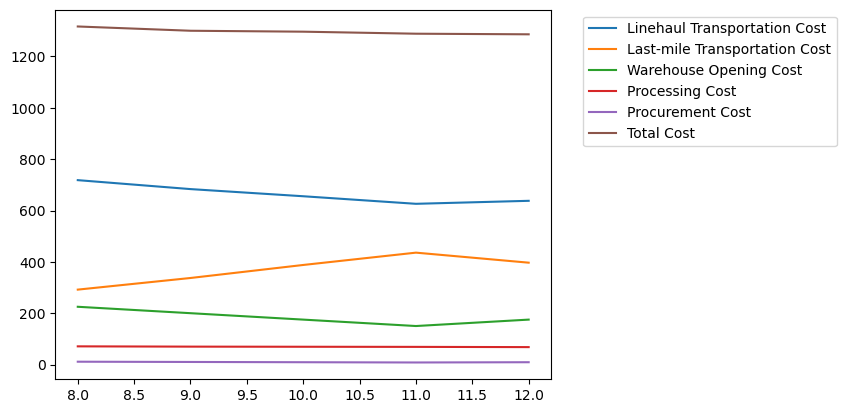

In [74]:
Dura_std_list = range(8, 13)
model.setParam(COPT.Param.Logging, False)

kpi_trans0 = []
kpi_trans1 = []
kpi_opening = []
kpi_process = []
kpi_procure = []
kpi_sum = []

for Dura_std in Dura_std_list:
    Dura_ind = {}
    for key, value in Dura.items():
        if value <= Dura_std * 60:
            Dura_ind[key] = 1
        else:
            Dura_ind[key] = 0

    # Remove the original constraint and add a new one
    model.remove(time_constr)
    time_constr = model.addConstr(
        cp.quicksum(Dura_ind[i, k] * d_cust[i, k, s] for i in dc_list for k in cust_list for s in sku_list) >=
        P_dura * cp.quicksum(D[k, s] for k in cust_list for s in sku_list)
    )

    # Solve the model
    model.setParam("logging", 0)
    model.solve()
    # model.writeLp("Revised.lp")

    # Collect KPI data
    kpi_trans0.append(sum(qty_dc[i, j, s].X * Cost_trans[i, j] for (i, j, s) in dc_flow_idx))
    kpi_trans1.append(sum(d_cust[i, k, s].X * Cost_trans[i, k] for i in dc_list for k in cust_list for s in sku_list))
    kpi_opening.append(sum(wh[i].X * Cost_wh[i] for i in dc_list))
    kpi_process.append(sum(proc[i].X * Proc_cost[i] for i in dc_list))
    kpi_procure.append(sum(procure[i].X * Procure_cost for i in dc_list))
    kpi_sum.append(kpi_trans0[-1] + kpi_trans1[-1] + kpi_opening[-1] + kpi_process[-1] + kpi_procure[-1])

# Plot the results
plt.plot(Dura_std_list, kpi_trans0, label='Linehaul Transportation Cost')
plt.plot(Dura_std_list, kpi_trans1, label='Last-mile Transportation Cost')
plt.plot(Dura_std_list, kpi_opening, label='Warehouse Opening Cost')
plt.plot(Dura_std_list, kpi_process, label='Processing Cost')
plt.plot(Dura_std_list, kpi_procure, label='Procurement Cost')
plt.plot(Dura_std_list, kpi_sum, label='Total Cost')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## 2. Lead Time Satisfaction Rate (Original: 0.95)
Change the parameter to vary between 75% and 95% and observe the impact.

Setting parameter 'Logging' to 1
0.75
[1286.3011314999999]
0.8
[1286.3011314999999, 1286.3011314999999]
0.8500000000000001
[1286.3011314999999, 1286.3011314999999, 1286.931998]
0.9
[1286.3011314999999, 1286.3011314999999, 1286.931998, 1296.7442735]
0.9500000000000001
[1286.3011314999999, 1286.3011314999999, 1286.931998, 1296.7442735, 1316.944237]


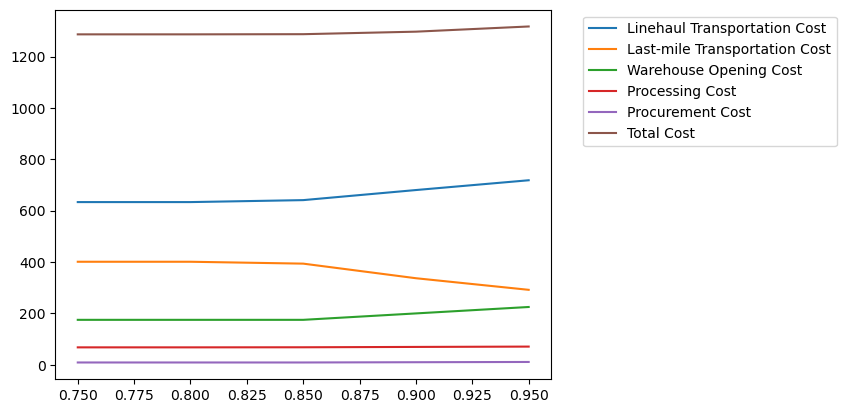

In [76]:
Dura_std = 480
P_dura_list = [i * 0.05 for i in range(15, 20)]
model.setParam(COPT.Param.Logging, True)

kpi_trans0 = []
kpi_trans1 = []
kpi_opening = []
kpi_process = []
kpi_procure = []
kpi_sum = []

# Generate new delivery-time satisfaction data
Dura_ind = {}
for key, value in Dura.items():
    if value <= Dura_std:
        Dura_ind[key] = 1
    else:
        Dura_ind[key] = 0

for P_dura in P_dura_list:
    print(P_dura)

    # Remove the original constraint and add a new one
    model.remove(time_constr)
    time_constr = model.addConstr(
        cp.quicksum(Dura_ind[i, k] * d_cust[i, k, s] for i in dc_list for k in cust_list for s in sku_list) >=
        P_dura * cp.quicksum(D[k, s] for k in cust_list for s in sku_list)
    )

    # Solve the model
    model.setParam("logging", 0)
    model.solve()

    # Collect KPI data
    kpi_trans0.append(sum(qty_dc[i, j, s].X * Cost_trans[i, j] for (i, j, s) in dc_flow_idx))
    kpi_trans1.append(sum(d_cust[i, k, s].X * Cost_trans[i, k] for i in dc_list for k in cust_list for s in sku_list))
    kpi_opening.append(sum(wh[i].X * Cost_wh[i] for i in dc_list))
    kpi_process.append(sum(proc[i].X * Proc_cost[i] for i in dc_list))
    kpi_procure.append(sum(procure[i].X * Procure_cost for i in dc_list))
    kpi_sum.append(kpi_trans0[-1] + kpi_trans1[-1] + kpi_opening[-1] + kpi_process[-1] + kpi_procure[-1])

    print(kpi_sum)

# Plot the results
plt.plot(P_dura_list, kpi_trans0, label='Linehaul Transportation Cost')
plt.plot(P_dura_list, kpi_trans1, label='Last-mile Transportation Cost')
plt.plot(P_dura_list, kpi_opening, label='Warehouse Opening Cost')
plt.plot(P_dura_list, kpi_process, label='Processing Cost')
plt.plot(P_dura_list, kpi_procure, label='Procurement Cost')
plt.plot(P_dura_list, kpi_sum, label='Total Cost')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()